# MOE Profiler - Load Balancing and Performance Analysis

This notebook analyzes and visualizes load balancing and performance metrics for the Mixture of Experts (MoE) profiler, comparing elbow-based expert selection with the original fixed top-k approach.

## Requirements
- Python 3.8+
- pandas>=1.3.0
- numpy>=1.21.0
- matplotlib>=3.4.0
- torch>=1.9.0
- cycler>=0.10.0

## Setup

1. Set the `DATA_DIR` variable below to point to your benchmark results directory
2. Ensure the pickle files are organized in subdirectories:
   - `{DATA_DIR}/k_and_flops/` - Contains topk_stats and fullanalysis pkl files
   - `{DATA_DIR}/latency/` - Contains latency pkl files
   
   For example: 
   ```
   data/
   ├── k_and_flops/
   │   ├── mmlu_topk_stats_elbow.pkl
   │   ├── mmlu_topk_stats_original.pkl
   │   ├── mmlu_fullanalysis_elbow.pkl
   │   ├── mmlu_fullanalysis_original.pkl
   │   └── ...
   └── latency/
      ├── mmlu_elbow.pkl
      ├── mmlu_original.pkl
      └── ...
   ```

## Data File Naming Convention

Expected pkl file names:
- `{benchmark}_topk_stats_elbow.pkl` / `{benchmark}_topk_stats_original.pkl`
- `{benchmark}_fullanalysis_elbow.pkl` / `{benchmark}_fullanalysis_original.pkl`
- `{benchmark}_elbow.pkl` / `{benchmark}_original.pkl` (for latency)

where `{benchmark}` is one of: arc_challenge, arc_easy, hellaswag, mmlu, piqa, winogrande

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

cmap = plt.cm.get_cmap("tab10", 6)
colors = [cmap(i) for i in range(6)]

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'axes.prop_cycle': cycler(color=colors)
})

/tmp/ipython-input-2997493946.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 6)


In [ ]:
import os
from pathlib import Path

# Configuration: Set this to your data directory
# Example: DATA_DIR = Path("/path/to/benchmark/results")
DATA_DIR = Path("./data")

# Subdirectories for different data types
FLOPS_DIR = DATA_DIR / "k_and_flops"
LATENCY_DIR = DATA_DIR / "latency"

# Create directories if needed (for reference)
FLOPS_DIR.mkdir(parents=True, exist_ok=True)
LATENCY_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory configured: {DATA_DIR.absolute()}")
print(f"Looking for k_and_flops data in: {FLOPS_DIR.absolute()}")
print(f"Looking for latency data in: {LATENCY_DIR.absolute()}")

In [ ]:
# Google Colab only: Uncomment to mount Google Drive if running in Colab
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pickle
from pathlib import Path
from typing import Any

def unpickle(path: str | Path, *, encoding: str = "latin1") -> Any:
    """
    Load (unpickle) a Python object from `path`.
    
    Args:
        path: Path to pickle file
        encoding: Encoding to use if standard unpickling fails
        
    Returns:
        Unpickled Python object
        
    Raises:
        FileNotFoundError: If the pickle file does not exist
    """
    path = Path(path)
    
    if not path.exists():
        raise FileNotFoundError(
            f"Pickle file not found: {path.absolute()}\n"
            f"Please ensure the file exists or check DATA_DIR configuration."
        )
    
    with path.open("rb") as f:
        try:
            return pickle.load(f)
        except UnicodeDecodeError:
            # Likely a Py2 pickle; retry with explicit encoding
            f.seek(0)
            return pickle.load(f, encoding=encoding)

In [ ]:
try:
    arceasy = unpickle(FLOPS_DIR / "arc_easy_topk_stats_elbow.pkl")
    arceasyog = unpickle(FLOPS_DIR / "arc_easy_topk_stats_original.pkl")
    
    hellaswag = unpickle(FLOPS_DIR / "hellaswag_topk_stats_elbow.pkl")
    hellaswagog = unpickle(FLOPS_DIR / "hellaswag_topk_stats_original.pkl")
    
    piqa = unpickle(FLOPS_DIR / "piqa_topk_stats_elbow.pkl")
    piqaog = unpickle(FLOPS_DIR / "piqa_topk_stats_original.pkl")
    
    winogrande = unpickle(FLOPS_DIR / "winogrande_topk_stats_elbow.pkl")
    winograndeog = unpickle(FLOPS_DIR / "winogrande_topk_stats_original.pkl")

    arcchallenge = unpickle(FLOPS_DIR / "arc_challenge_topk_stats_elbow.pkl")
    arcchallengeog = unpickle(FLOPS_DIR / "arc_challenge_topk_stats_original.pkl")

    mmlu = unpickle(FLOPS_DIR / "mmlu_topk_stats_elbow.pkl")
    mmluog = unpickle(FLOPS_DIR / "mmlu_topk_stats_original.pkl")
    
    print("Successfully loaded arc_easy, hellaswag, piqa, winogrande, arc_challenge and mmlu stats")
except FileNotFoundError as e:
    print(f"Error loading stats: {e}")

In [ ]:
import torch
import matplotlib.pyplot as plt

def k_analysis(stats):
  layers = []
  for i in stats.keys():
    allkprefill = torch.cat(stats[i]['k_prefill'])
    allkdecode = torch.cat(stats[i]['k_decode'])
    total = np.array(torch.cat([allkprefill,allkdecode]))
    layers.append(round(total.mean(),5))
  return layers, round(np.array(layers).mean(),5)

def plot_layers_by_dataset(layers_by_name: dict[str, list[float]], *, title="Layer values by dataset"):
    """
    layers_by_name: {"arceasy": [..floats..], "mmlu": [..], ...}
    Plots all series on one line chart with a legend.
    """
    plt.figure(figsize=(6,5))
    for name, layers in layers_by_name.items():
        x = range(len(layers))
        plt.plot(x, layers, label=name)

    plt.xlabel("Layer")
    plt.ylabel("Average # Experts Used")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig("layers_by_dataset.pdf")
    plt.show()


In [ ]:
datasets = {
    "arcchallenge": arcchallenge,
    "arceasy": arceasy,
    "hellaswag": hellaswag,
    "mmlu": mmlu,
    "piqa": piqa,
    "winogrande": winogrande,
}

layers_by_name = {}
means_by_name = {}

for name, d in datasets.items():
    layers, meank = k_analysis(d)
    layers_by_name[name] = layers
    means_by_name[name] = meank
    print(f"{name}: mean={round(meank,3)}")

arcchallenge: mean=7.634
arceasy: mean=7.623
hellaswag: mean=7.655
mmlu: mean=7.613
piqa: mean=7.589
winogrande: mean=7.576


In [ ]:
sum = 0
for k,v in means_by_name.items():
  sum += v
print(f"Overall mean: {round(sum/len(means_by_name),6)}")

Overall mean: 7.61488


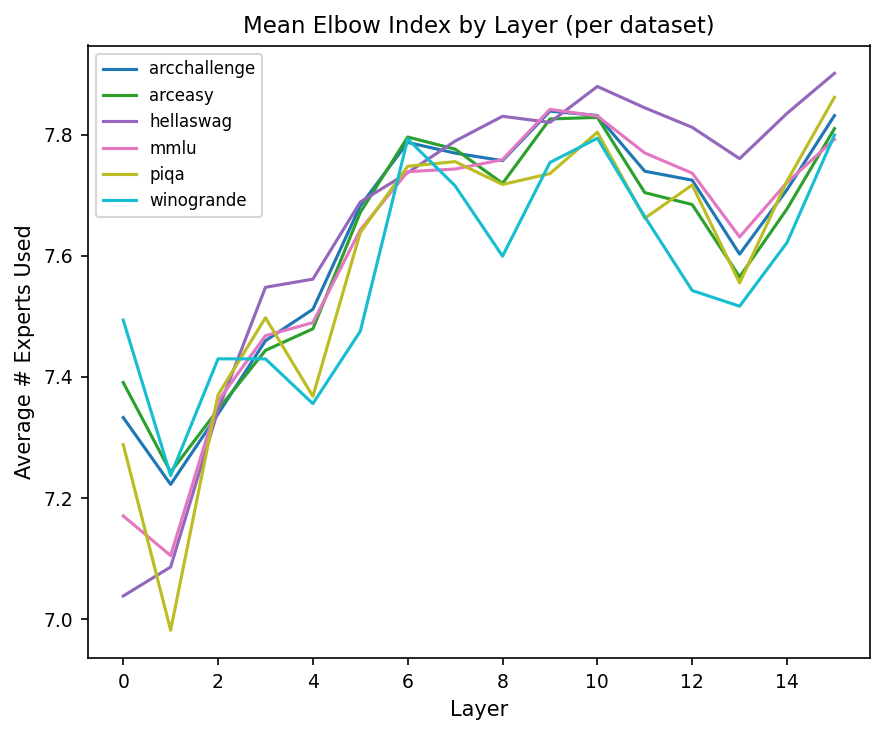

In [ ]:
plot_layers_by_dataset(layers_by_name, title="Mean Elbow Index by Layer (per dataset)")


In [ ]:
def flops_analysis(stats,original=False):
  layers = []
  if original:
    key = "original_flops_decode"
  else:
    key = "flops_decode"
  for i in stats.keys():
    layers.append(np.array(stats[i][key]).mean())
  return np.array(layers).mean()

In [ ]:
datasetsog = {
    "arcchallengeog": arcchallengeog,
    "arceasyog": arceasyog,
    "hellaswagog": hellaswagog,
    "mmluog": mmluog,
    "piqaog": piqaog,
    "winograndeog": winograndeog,
}

for name, d in datasetsog.items():
    flops = flops_analysis(d,original=True)
    print(f"{name}: mean={flops:.3e}")

for name, d in datasets.items():
    flops = flops_analysis(d)
    print(f"{name}: mean={flops:.3e}")


arcchallengeog: mean=5.372e+08
arceasyog: mean=5.372e+08
hellaswagog: mean=5.372e+08
mmluog: mean=5.372e+08
piqaog: mean=5.372e+08
winograndeog: mean=5.372e+08
arcchallenge: mean=4.881e+08
arceasy: mean=4.862e+08
hellaswag: mean=4.919e+08
mmlu: mean=4.906e+08
piqa: mean=4.854e+08
winogrande: mean=4.805e+08


In [ ]:
try:
    archallengelatency = unpickle(LATENCY_DIR / "arc_challenge_elbow.pkl")
    arcchallengelatencyog = unpickle(LATENCY_DIR / "arc_challenge_original.pkl")
    arceasylatency = unpickle(LATENCY_DIR / "arc_easy_elbow.pkl")
    arceasylatencyog = unpickle(LATENCY_DIR / "arc_easy_original.pkl")
    hellaswaglatency = unpickle(LATENCY_DIR / "hellaswag_elbow.pkl")
    hellaswaglatencyog = unpickle(LATENCY_DIR / "hellaswag_original.pkl")
    mmlulatency = unpickle(LATENCY_DIR / "mmlu_elbow.pkl")
    mmlulatencyog = unpickle(LATENCY_DIR / "mmlu_original.pkl")
    piqalatency = unpickle(LATENCY_DIR / "piqa_elbow.pkl")
    piqalatencyog = unpickle(LATENCY_DIR / "piqa_original.pkl")
    winograndelatency = unpickle(LATENCY_DIR / "winogrande_elbow.pkl")
    winograndelatencyog = unpickle(LATENCY_DIR / "winogrande_original.pkl")
    
    print("Successfully loaded all latency data")
except FileNotFoundError as e:
    print(f"Error loading latency data: {e}")

In [ ]:
import numpy as np

latency_lists = {
    "arc_challenge_dynamic": archallengelatency,
    "arc_challenge_original": arcchallengelatencyog,
    "arc_easy_dynamic": arceasylatency,
    "arc_easy_original": arceasylatencyog,
    "hellaswag_dynamic": hellaswaglatency,
    "hellaswag_original": hellaswaglatencyog,
    "mmlu_dynamic": mmlulatency,
    "mmlu_original": mmlulatencyog,
    "piqa_dynamic": piqalatency,
    "piqa_original": piqalatencyog,
    "winogrande_dynamic": winogrande,
    "winogrande_original": winograndeog,
}

for name, xs in latency_lists.items():
    mean_ms = float(np.mean(xs)) * 1000.0
    print(f"{name}: {mean_ms:.3f} ms")

arc_challenge_dynamic: 10.974 ms
arc_challenge_original: 11.531 ms
arc_easy_dynamic: 10.497 ms
arc_easy_original: 11.203 ms
hellaswag_dynamic: 13.960 ms
hellaswag_original: 14.630 ms
mmlu_dynamic: 12.571 ms
mmlu_original: 13.287 ms
piqa_dynamic: 12.944 ms
piqa_original: 13.398 ms
winogrande_dynamic: 8.948 ms
winogrande_original: 9.659 ms


In [ ]:
latency = [(10.974,11.531),(10.497,11.203),(13.960,14.630),(12.571,13.287),(12.944,13.398),(8.948,9.659)]

x = 0
for pair in latency:
  x += (pair[0]-pair[1])/pair[1]

print(x/len(latency))


-0.053083788474523524


In [ ]:
try:
    arcchallengeaccuracy = unpickle(FLOPS_DIR / "arc_challenge_fullanalysis_elbow.pkl")
    arcchallengeaccuracyog = unpickle(FLOPS_DIR / "arc_challenge_fullanalysis_original.pkl")
    arceasyaccuracy = unpickle(FLOPS_DIR / "arc_easy_fullanalysis_elbow.pkl")
    arceasyaccuracyog = unpickle(FLOPS_DIR / "arc_easy_fullanalysis_original.pkl")
    hellaswagaccuracy = unpickle(FLOPS_DIR / "hellaswag_fullanalysis_elbow.pkl")
    hellaswagaccuracyog = unpickle(FLOPS_DIR / "hellaswag_fullanalysis_original.pkl")
    mmluaccuracy = unpickle(FLOPS_DIR / "mmlu_fullanalysis_elbow.pkl")
    mmluaccuracyog = unpickle(FLOPS_DIR / "mmlu_fullanalysis_original.pkl")
    piqaaccuracy = unpickle(FLOPS_DIR / "piqa_fullanalysis_elbow.pkl")
    piqaaccuracyog = unpickle(FLOPS_DIR / "piqa_fullanalysis_original.pkl")
    winograndeaccuracy = unpickle(FLOPS_DIR / "winogrande_fullanalysis_elbow.pkl")
    winograndeaccuracyog = unpickle(FLOPS_DIR / "winogrande_fullanalysis_original.pkl")
    
    print("Successfully loaded all accuracy analysis data")
except FileNotFoundError as e:
    print(f"Error loading accuracy data: {e}")

In [ ]:
def accuracy_analysis(data):
  num_correct = sum(d["answer"] == d["generatedanswer"] for d in data)
  print(f"Accuracy: {num_correct / len(data) * 100:.2f}%")

In [ ]:
accuracy_datasets = {
    "arcchallenge_dynamic": arcchallengeaccuracy,
    "arcchallenge_original": arcchallengeaccuracyog,
    "arceasy_dynamic": arceasyaccuracy,
    "arceasy_original": arceasyaccuracyog,
    "hellaswag_dynamic": hellaswagaccuracy,
    "hellaswag_original": hellaswagaccuracyog,
    "mmlu_dynamic": mmluaccuracy,
    "mmlu_original": mmluaccuracyog,
    "piqa_dynamic": piqaaccuracy,
    "piqa_original": piqaaccuracyog,
    "winogrande_dynamic": winograndeaccuracy,
    "winogrande_original": winograndeaccuracyog,
}

for name, data in accuracy_datasets.items():
    print(f"--- {name} ---")
    accuracy_analysis(data)

--- arcchallenge_dynamic ---
Accuracy: 62.29%
--- arcchallenge_original ---
Accuracy: 61.86%
--- arceasy_dynamic ---
Accuracy: 78.24%
--- arceasy_original ---
Accuracy: 77.82%
--- hellaswag_dynamic ---
Accuracy: 46.86%
--- hellaswag_original ---
Accuracy: 47.02%
--- mmlu_dynamic ---
Accuracy: 51.75%
--- mmlu_original ---
Accuracy: 51.74%
--- piqa_dynamic ---
Accuracy: 72.85%
--- piqa_original ---
Accuracy: 73.18%
--- winogrande_dynamic ---
Accuracy: 50.28%
--- winogrande_original ---
Accuracy: 50.36%


In [ ]:
import numpy as np
import pandas as pd
import torch

def analyze_load_balancing_summary(dynamic_topk_stats, original: bool = False) -> pd.DataFrame:
    rows = []

    def _flatten(seq):
        for x in seq:
            if isinstance(x, (list, tuple)):
                yield from _flatten(x)
            else:
                yield x

    for layer_id in sorted([k for k in dynamic_topk_stats.keys() if isinstance(k, int)]):
        if original:
            pre = dynamic_topk_stats[layer_id].get("original_expert_usage_prefill", [])
            dec = dynamic_topk_stats[layer_id].get("original_expert_usage_decode", [])
            method_name = "original_k8"
        else:
            pre = dynamic_topk_stats[layer_id].get("expert_usage_prefill", [])
            dec = dynamic_topk_stats[layer_id].get("expert_usage_decode", [])
            method_name = "elbow-8"

        # Combine and flatten (handles list-of-lists)
        layer_data = list(_flatten(list(pre) + list(dec)))

        # Keep only tensors (guards against accidental non-tensor entries)
        layer_data = [t for t in layer_data if torch.is_tensor(t)]

        if len(layer_data) == 0:
            # No data for this layer; skip (or append NaNs if you prefer)
            continue

        usage = torch.stack(layer_data).sum(dim=0).detach().cpu().numpy()
        total_calls = float(usage.sum())
        usagepercent = np.round((usage/total_calls),6)
        n_experts = int(len(usage))

        ideal = (total_calls / n_experts) if n_experts > 0 else 0.0
        std_dev = float(np.std(usage)) if n_experts > 0 else 0.0
        coeff_var_pct = (std_dev / ideal) if ideal > 0 else 0.0

        rows.append({
            "layer_id": layer_id,
            "method": method_name,
            "unnormusage": usage,
            "usage": usagepercent,
            "std_dev": std_dev,
            "mean": ideal,
            "coeff_var_pct": coeff_var_pct,
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["layer_id", "method"]).reset_index(drop=True)
    return df

def cvdiff(elbow,original):
  m = elbow.merge(
      original,
      on="layer_id",
      how="inner",
      suffixes=("_elbow", "_og")
  )

  # elbow - og for coeff_var_pct
  m["coeff_var_pct_diff"] = m["coeff_var_pct_elbow"] - m["coeff_var_pct_og"]
  return list(m["coeff_var_pct_diff"]), m["coeff_var_pct_diff"].mean(), np.median(m["coeff_var_pct_diff"])

def plotloadbalancebylayer(df,layer,title):

  methods = ["elbow-8", "original_k8"]

  # ---- filter + validate ----
  df0 = df[df["layer_id"].eq(layer) & df["method"].isin(methods)].copy()

  if df0.empty:
      raise ValueError(f"No rows found for layer_id={layer} and methods={methods}.")

  counts = df0["method"].value_counts()
  missing = [m for m in methods if m not in counts.index]
  if missing:
      raise ValueError(f"Missing method(s) for layer_id={layer}: {missing}")

  # If duplicates exist, pick the first (adjust if you want different behavior)
  df0 = df0.sort_values("method").drop_duplicates(subset=["method"], keep="first")

  usage_map = {}
  for m in methods:
      u = df0.loc[df0["method"].eq(m), "unnormusage"].iloc[0]
      arr = np.asarray(u, dtype=float)
      if arr.shape != (64,):
          raise ValueError(f"Expected 'usage' length 64 for method='{m}', got shape {arr.shape}.")
      usage_map[m] = arr

  elbow = usage_map["elbow-8"]
  orig  = usage_map["original_k8"]
  diff  = elbow - orig

  # ---- plot (two rows) ----
  x = np.arange(64)
  width = 0.4

  fig, (ax1, ax2) = plt.subplots(
      2, 1, figsize=(15, 8),
      gridspec_kw={"height_ratios": [2, 1]},
      sharex=True
  )

  # Top: grouped bars
  ax1.bar(x - width/2, elbow, width, label="elbow-8")
  ax1.bar(x + width/2, orig,  width, label="baseline")
  ax1.set_title(f"Expert Usage by index (layer_id={layer})")
  ax1.set_ylabel("Usage")
  ax1.legend()

  # Bottom: difference bars
  ax2.bar(x, diff)
  ax2.axhline(0, linewidth=1)
  ax2.set_title("Difference (elbow-8 − baseline)")
  ax2.set_xlabel("Expert Index (0..63)")
  ax2.set_ylabel("Δ Usage")

  ax2.set_xticks(x)
  ax2.set_xlim(-1, 64)

  plt.tight_layout()
  plt.savefig(f"{title}.pdf")
  plt.show()


In [ ]:
datasets = {
    "arcchallenge": arcchallenge,
    "arceasy": arceasy,
    "hellaswag": hellaswag,
    "mmlu": mmlu,
    "piqa": piqa,
    "winogrande": winogrande,
}

datasetsog = {
    "arcchallengeog": arcchallengeog,
    "arceasyog": arceasyog,
    "hellaswagog": hellaswagog,
    "mmluog": mmluog,
    "piqaog": piqaog,
    "winograndeog": winograndeog,
}


In [ ]:
def sumqr(elbow,original):
  elbowlb = analyze_load_balancing_summary(elbow)
  oglb = analyze_load_balancing_summary(original,original=True)
  merged = elbowlb.merge(
    oglb,
    on='layer_id',
    how="inner",
    suffixes=("_elbow", "_og")
  )

  merged["unnormusage_diff_og_minus_elbow"] = (
      merged["unnormusage_og"] - merged["unnormusage_elbow"]
  )

  allsums = []
  topq = []
  topr = []
  for i in range(16):
    r = merged["unnormusage_diff_og_minus_elbow"].iloc[i]
    rnorm = r / np.sum(r)
    topr.append(np.max(rnorm))
    q = merged["usage_og"].iloc[i]
    topq.append(np.max(q))
    allsums.append(np.sum(rnorm*q))

  return allsums,topq,topr

def normsandtopq(elbow,original):
  elbowlb = analyze_load_balancing_summary(elbow)
  oglb = analyze_load_balancing_summary(original,original=True)
  merged = elbowlb.merge(
    oglb,
    on='layer_id',
    how="inner",
    suffixes=("_elbow", "_og")
  )

  merged["unnormusage_diff_og_minus_elbow"] = (
      merged["unnormusage_og"] - merged["unnormusage_elbow"]
  )

  l1normbylayer = []
  cvdiffbylayer = []
  topqdifflayer = []

  for i in range(16):
    q = merged["usage_og"].iloc[i]
    qelbow = merged["usage_elbow"].iloc[i]
    l1norm = np.sum(np.abs(q-qelbow))
    l1normbylayer.append(l1norm)
    cvdiffbylayer.append((merged["coeff_var_pct_og"].iloc[i]-merged["coeff_var_pct_elbow"].iloc[i])/merged["coeff_var_pct_og"].iloc[i])
    topqdiff = np.max(q) - np.max(qelbow)
    topqdifflayer.append(topqdiff/np.max(q))

  return l1normbylayer, cvdiffbylayer, topqdifflayer

def rq(elbow,original):
  elbowlb = analyze_load_balancing_summary(elbow)
  oglb = analyze_load_balancing_summary(original,original=True)
  merged = elbowlb.merge(
    oglb,
    on='layer_id',
    how="inner",
    suffixes=("_elbow", "_og")
  )

  merged["unnormusage_diff_og_minus_elbow"] = (
      merged["unnormusage_og"] - merged["unnormusage_elbow"]
  )

  l1normbylayer = []

  for i in range(16):
    q = merged["usage_og"].iloc[i]
    qelbow = merged["usage_elbow"].iloc[i]
    r = merged["unnormusage_diff_og_minus_elbow"].iloc[i]
    rnorm = r / np.sum(r)
    l1norm = np.sum(np.abs(q-rnorm))
    l1normbylayer.append(l1norm)

  return l1normbylayer

In [ ]:
alll1norms = []

for i,name in enumerate(datasets.keys()):
  l1norm = rq(datasets[name],datasetsog[list(datasetsog.keys())[i]])
  alll1norms.append(np.array(l1norm))

l1normmeans = np.mean(np.array(alll1norms),axis=0)
l1normmeans

array([0.51148685, 0.4557376 , 0.49618458, 0.5979004 , 0.63400196,
       0.60587452, 0.69285545, 0.6112021 , 0.93807078, 0.9122946 ,
       0.87886633, 0.89133922, 0.91699538, 0.89882073, 0.82756396,
       0.89736383])

In [ ]:
allcvdiffs = {}
elbowmeans = {}
ogmeans = {}
allcvs = {}
for i,elbowdf in enumerate(datasets.keys()):
  elbow = analyze_load_balancing_summary(datasets[elbowdf])
  og = analyze_load_balancing_summary(datasetsog[list(datasetsog.keys())[i]],original=True)
  elbowmeans[elbowdf] = elbow["coeff_var_pct"].mean()
  ogmeans[elbowdf] = og["coeff_var_pct"].mean()
  cvlist, mean, median = cvdiff(elbow,og)
  allcvs[elbowdf] = {"elbow":elbow["coeff_var_pct"],"baseline":og["coeff_var_pct"]}
  allcvdiffs[elbowdf] = cvlist

In [ ]:
stackedl1norm = []
stackedcvratio = []
stackedtopqdiffratio = []

for key in alll1norms.keys():
  stackedl1norm.append(np.array(alll1norms[key]))
  stackedcvratio.append(np.array(allcvdiffs[key]))
  stackedtopqdiffratio.append(np.array(alltopqdiffs[key]))

In [ ]:
stackedl1normratio = np.array(stackedl1norm)
print(stackedl1normratio.shape)
stackedcvratio = np.array(stackedcvratio)
stackedtopqdiffratio = np.array(stackedtopqdiffratio)

(6, 16)


In [ ]:
l1normmeans = np.mean(stackedl1norm,axis=0)
topqdiffmeans = np.mean(stackedtopqdiffratio,axis=0)
cvmean = np.mean(stackedcvratio,axis=0)

In [ ]:
alldatasetsums = []
alltopq = []
alltopr = []
for i in range(6):
  singlesum,topq,topr = sumqr(datasets[i],datasetsog[i])
  alldatasetsums.extend(singlesum)
  alltopq.extend(topq)
  alltopr.extend(topr)

In [ ]:
allcvdiffs = {}
elbowmeans = {}
ogmeans = {}
allcvs = {}
for i,elbowdf in enumerate(datasets.keys()):
  elbow = analyze_load_balancing_summary(datasets[elbowdf])
  og = analyze_load_balancing_summary(datasetsog[list(datasetsog.keys())[i]],original=True)
  elbowmeans[elbowdf] = elbow["coeff_var_pct"].mean()
  ogmeans[elbowdf] = og["coeff_var_pct"].mean()
  cvlist, mean, median = cvdiff(elbow,og)
  allcvs[elbowdf] = {"elbow":elbow["coeff_var_pct"],"baseline":og["coeff_var_pct"]}
  allcvdiffs[elbowdf] = cvlist

In [ ]:
print(ogmeans)

{'arcchallenge': np.float64(0.747812330294548), 'arceasy': np.float64(0.7832341228590063), 'hellaswag': np.float64(0.5796790814141131), 'mmlu': np.float64(0.4749880825036801), 'piqa': np.float64(0.8016794772293117), 'winogrande': np.float64(0.7306933461570837)}


In [ ]:
print(elbowmeans)

{'arcchallenge': np.float64(0.7660790816128633), 'arceasy': np.float64(0.8017039095614159), 'hellaswag': np.float64(0.5966308860878514), 'mmlu': np.float64(0.48942660124194654), 'piqa': np.float64(0.8306845640636658), 'winogrande': np.float64(0.7464419665875712)}


In [ ]:
meandiff = 0
for k,v in elbowmeans.items():
  meandiff += (ogmeans[k] - v)/ogmeans[k]

meandiff/6

np.float64(-0.027563802722694167)

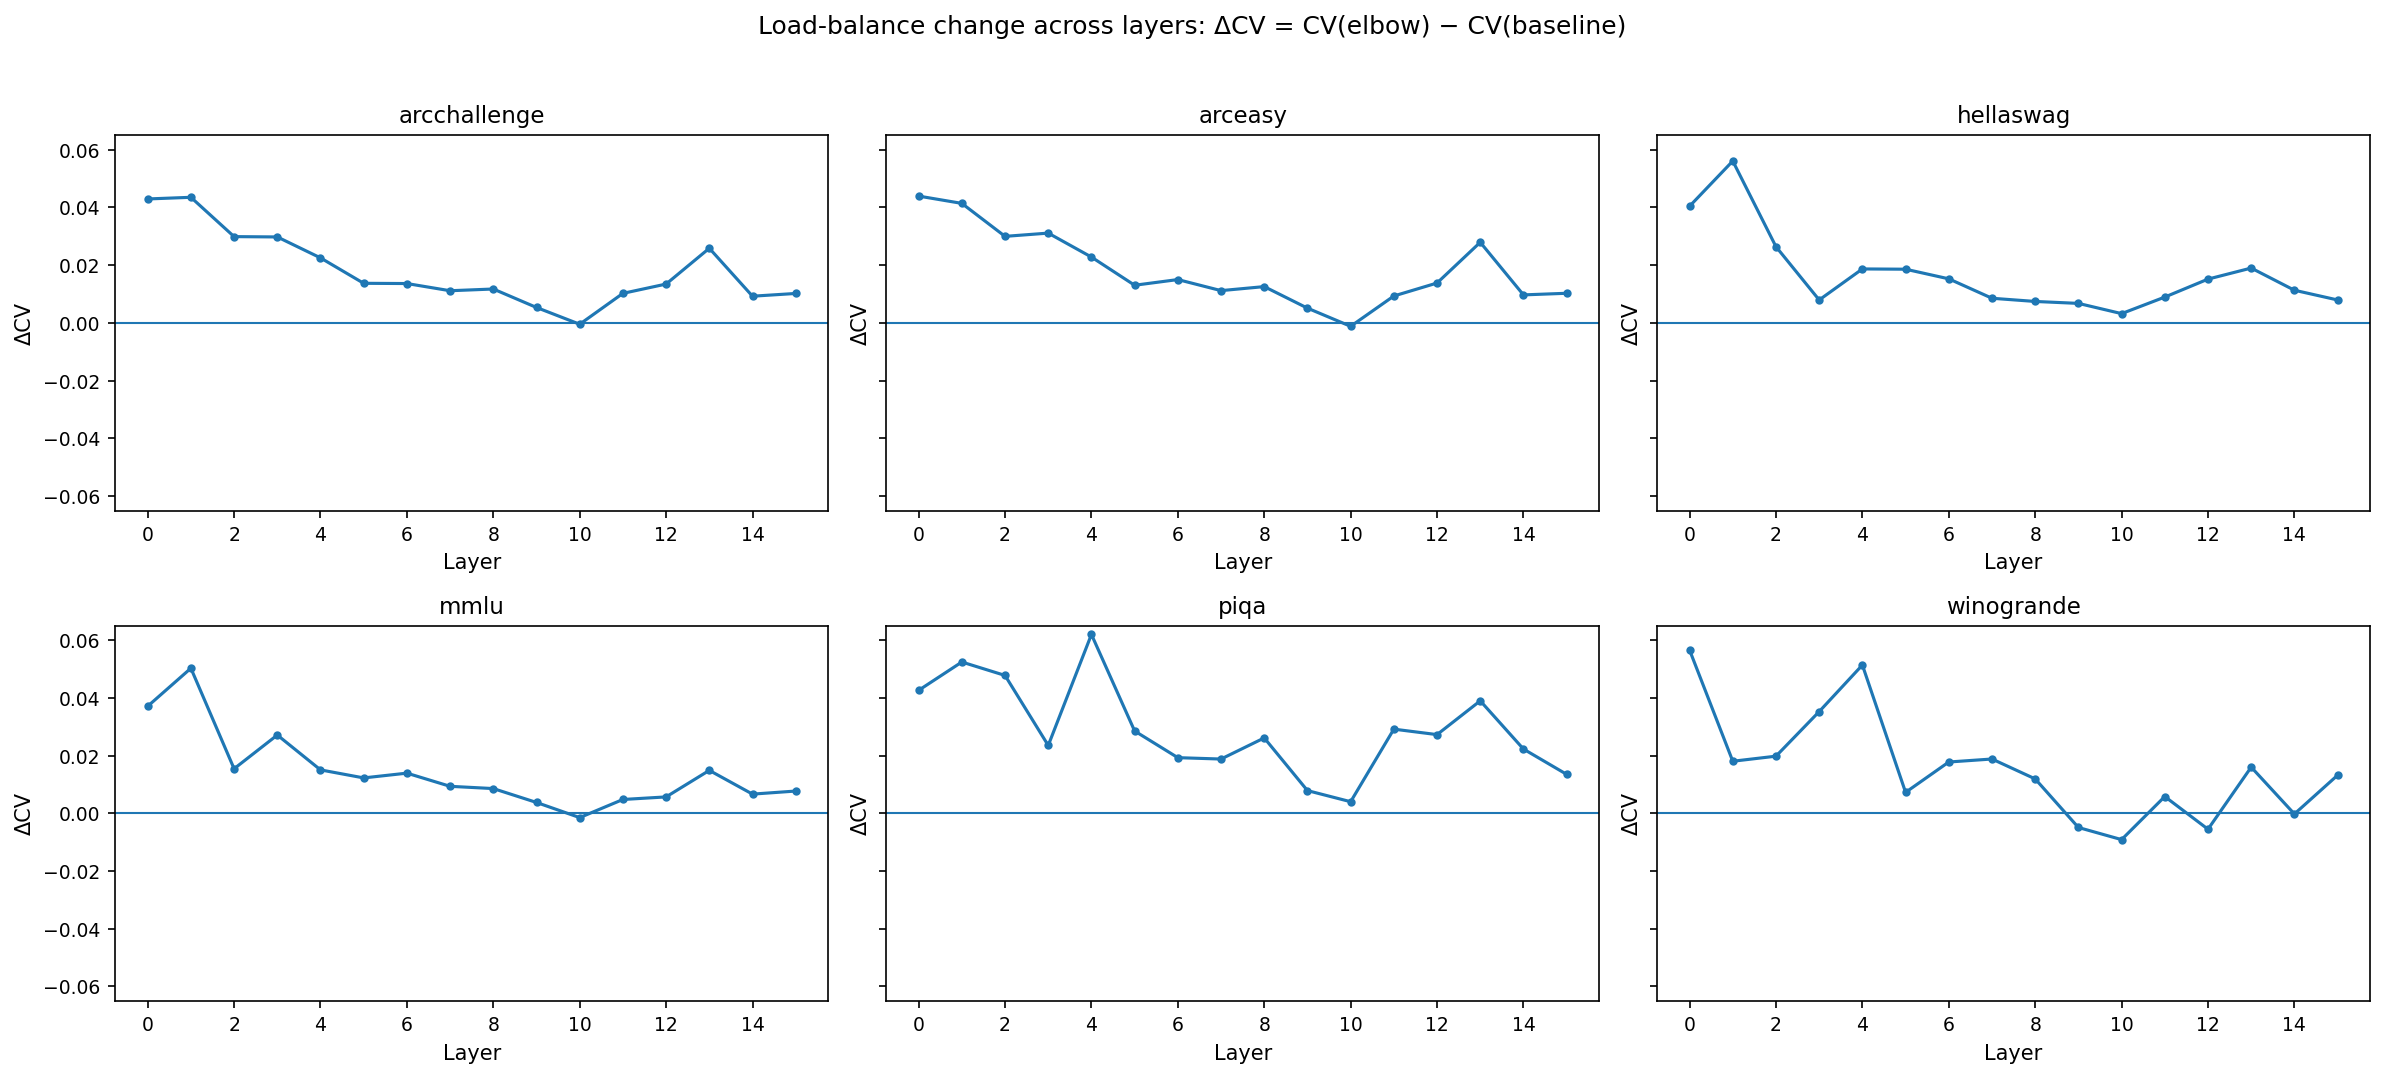

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = allcvs

datasets = ['arcchallenge', 'arceasy', 'hellaswag', 'mmlu', 'piqa', 'winogrande']

# --- prepare deltas + global y-lims for consistent scaling ---
deltas = {}
global_min, global_max = np.inf, -np.inf

for ds in datasets:
    if ds not in data:
        raise KeyError(f"Missing dataset key: {ds}")

    elbow = np.asarray(data[ds]["elbow"], dtype=float)
    base  = np.asarray(data[ds]["baseline"], dtype=float)

    if elbow.shape != base.shape:
        raise ValueError(f"{ds}: elbow and baseline must have same length, got {elbow.shape} vs {base.shape}")

    delta = elbow - base
    deltas[ds] = delta
    global_min = min(global_min, np.nanmin(delta))
    global_max = max(global_max, np.nanmax(delta))

# Add a small margin and make symmetric around 0
margin = 0.05 * max(abs(global_min), abs(global_max), 1e-12)
ylim = max(abs(global_min), abs(global_max)) + margin
ylims = (-ylim, ylim)

# --- plot: 2x3 small multiples of ΔCV over layers ---
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=False, sharey=True)
axes = axes.ravel()

for ax, ds in zip(axes, datasets):
    delta = deltas[ds]
    x = np.arange(len(delta))  # layer indices

    ax.plot(x, delta, marker="o", linewidth=1.5, markersize=3, label="ΔCV (elbow − baseline)")
    ax.axhline(0, linewidth=1)  # zero reference line

    ax.set_title(ds)
    ax.set_ylim(*ylims)
    ax.set_xlabel("Layer")
    ax.set_ylabel("ΔCV")

# Hide any unused axes if datasets list changes
for ax in axes[len(datasets):]:
    ax.axis("off")

fig.suptitle("Load-balance change across layers: ΔCV = CV(elbow) − CV(baseline)", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_dict_lists(data, *, kind="line", x=None, title=None,
                    xlabel="Layer", ylabel="Δ CV (Elbow - Baseline)"):
    if not isinstance(data, dict) or len(data) == 0:
        raise ValueError("data must be a non-empty dict of {label: list/array}.")

    labels = list(data.keys())
    ys = [np.asarray(data[k], dtype=float) for k in labels]
    n = len(ys[0])
    if any(len(y) != n for y in ys):
        raise ValueError("All lists in the dict must have the same length.")

    if x is None:
        x = np.arange(n)
    else:
        x = np.asarray(x)
        if len(x) != n:
            raise ValueError("x must have the same length as the value lists.")

    # colors from viridis
    cmap = plt.cm.get_cmap("tab10", len(labels))
    colors = [cmap(i) for i in range(len(labels))]

    plt.figure(figsize=(9, 3))

    if kind == "line":
        for (label, y, c) in zip(labels, ys, colors):
            plt.plot(x, y, label=label, color=c)
    elif kind == "bar":
        width = 0.8 / len(labels)
        offsets = (np.arange(len(labels)) - (len(labels) - 1) / 2) * width
        for (off, label, y, c) in zip(offsets, labels, ys, colors):
            plt.bar(x + off, y, width=width, label=label, color=c)
    else:
        raise ValueError("kind must be 'line' or 'bar'.")

    if title:
        plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(loc=1, fontsize='small')

    ax = plt.gca()
    ax.margins(x=0)
    ax.set_xticks(x)

    plt.tight_layout()
    plt.savefig(f"loadbalancing.pdf")
    plt.show()

# If you just want the raw RGBA color list:
# labels = list(data.keys())
# colors = [plt.cm.viridis(i/(len(labels)-1 if len(labels)>1 else 1)) for i in range(len(labels))]

/tmp/ipython-input-2430604467.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(labels))


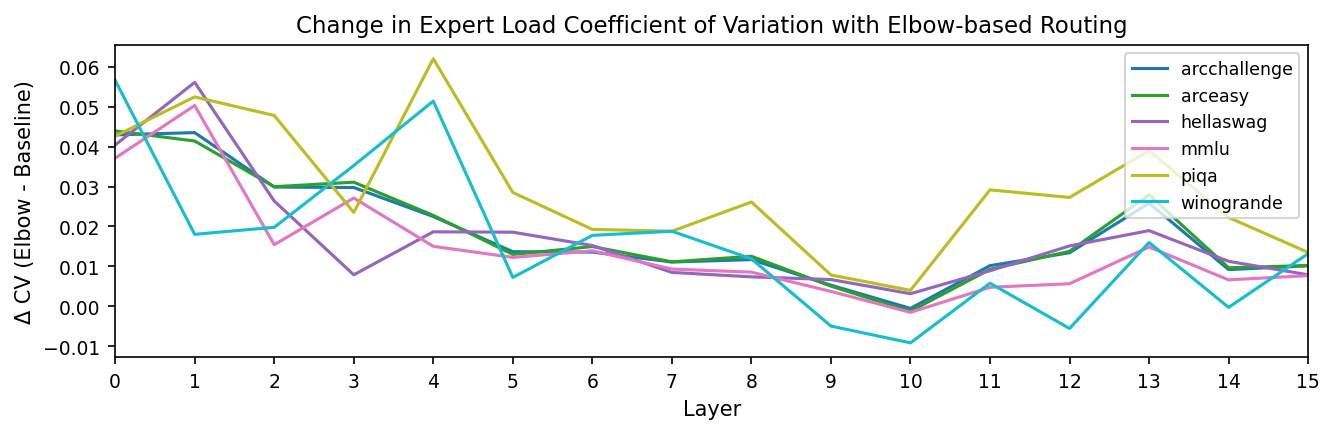

In [ ]:
plot_dict_lists(allcvdiffs, title="Change in Expert Load Coefficient of Variation with Elbow-based Routing")

In [ ]:
arccelbow = analyze_load_balancing_summary(arcchallenge)
arccog = analyze_load_balancing_summary(arcchallengeog,original=True)
arcchallengelb = pd.concat([arccelbow, arccog])
arcchallengelb.head()

In [ ]:
mmluelbowlb = analyze_load_balancing_summary(mmlu)
mmluoriginallb = analyze_load_balancing_summary(mmluog,original=True)
mmlulbcombined = pd.concat([mmluelbowlb,mmluoriginallb])

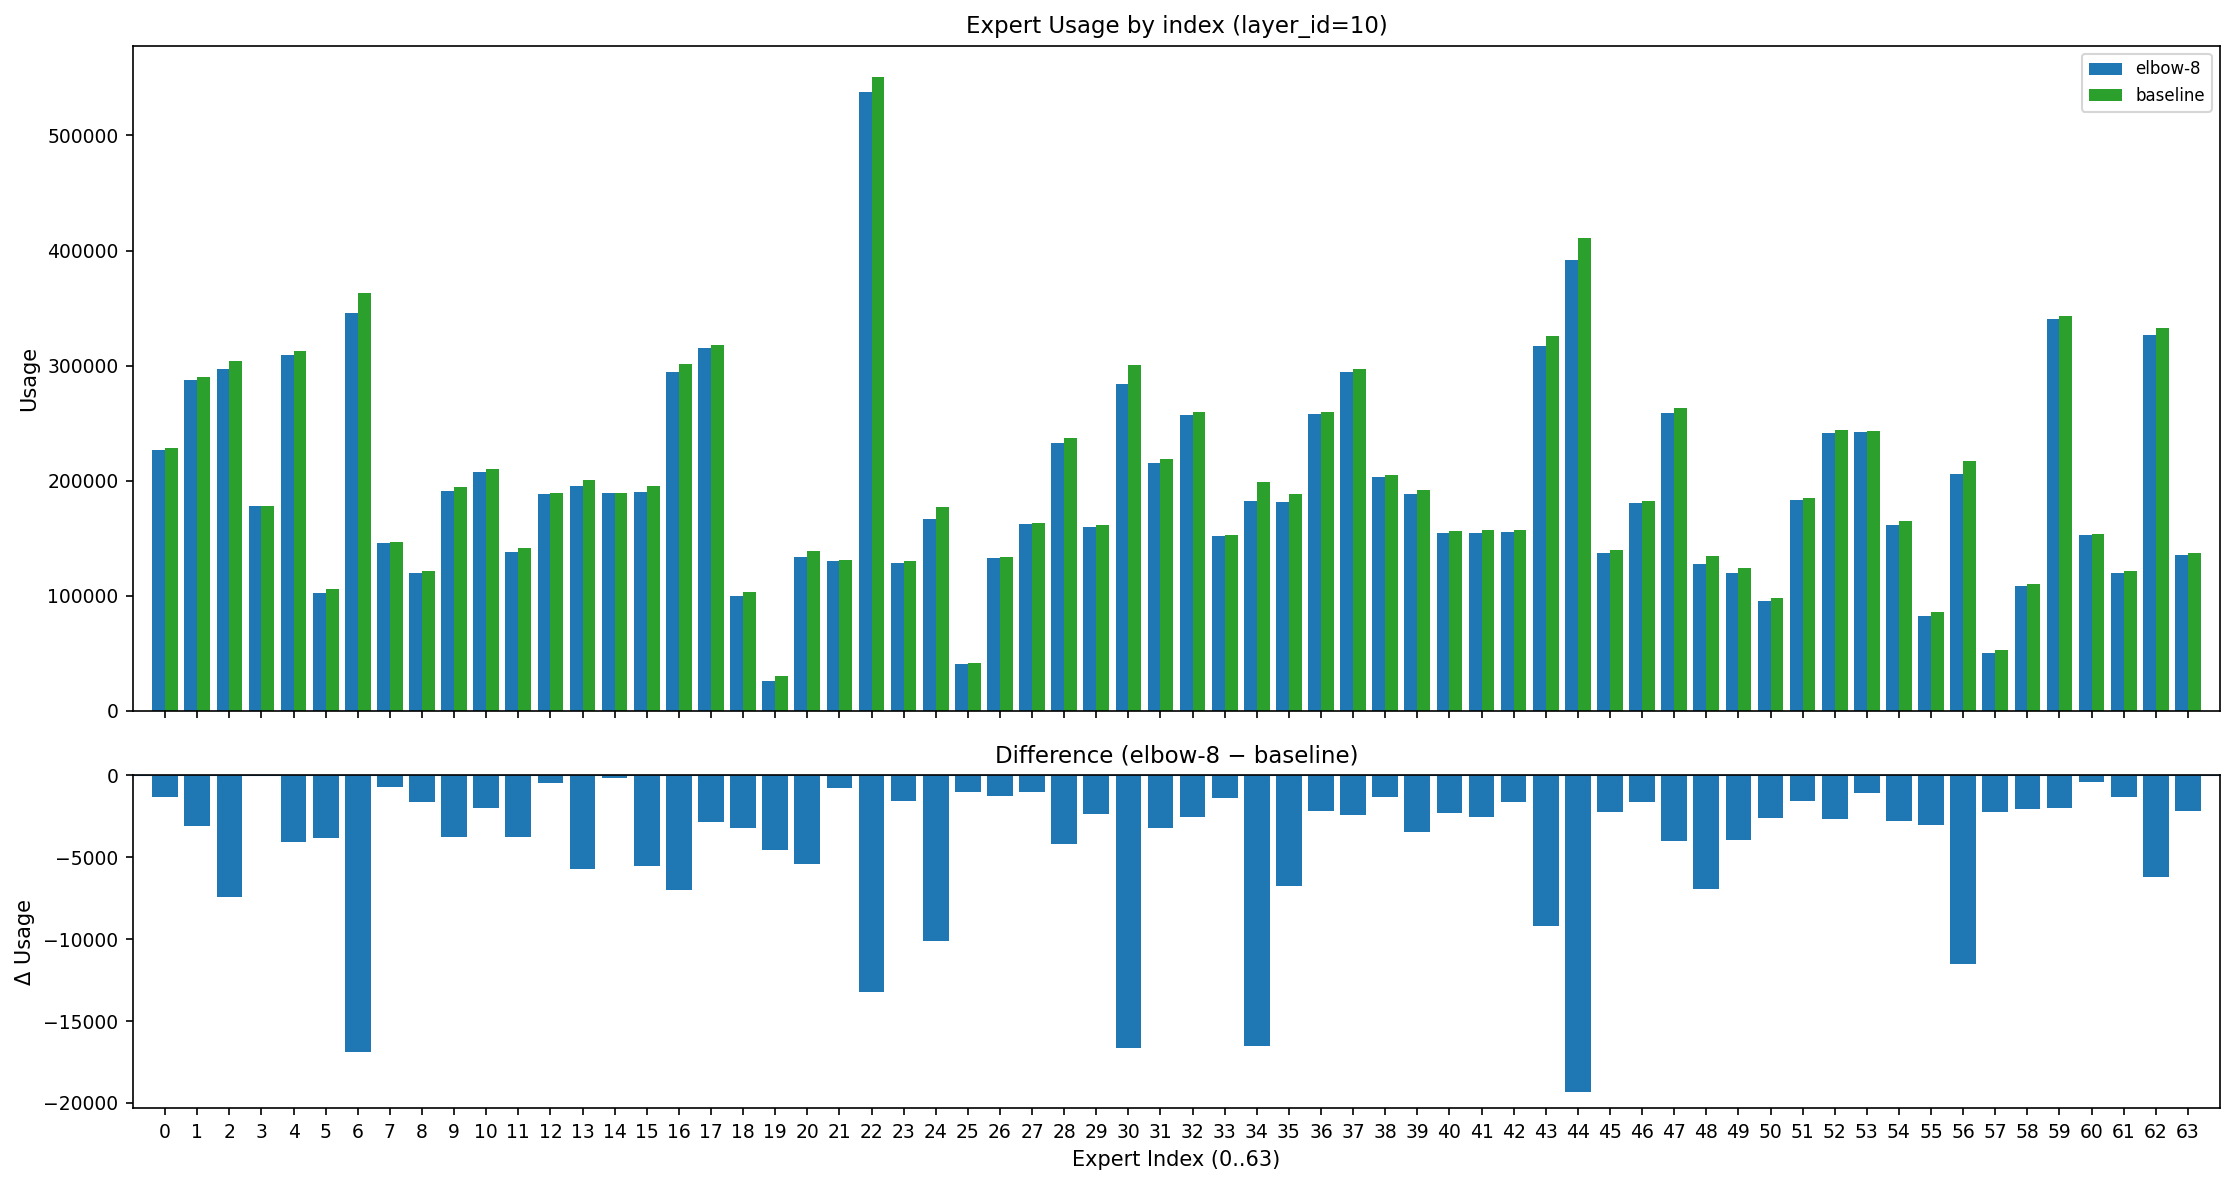

In [ ]:
plotloadbalancebylayer(mmlulbcombined,10,"load balance by layer 5")

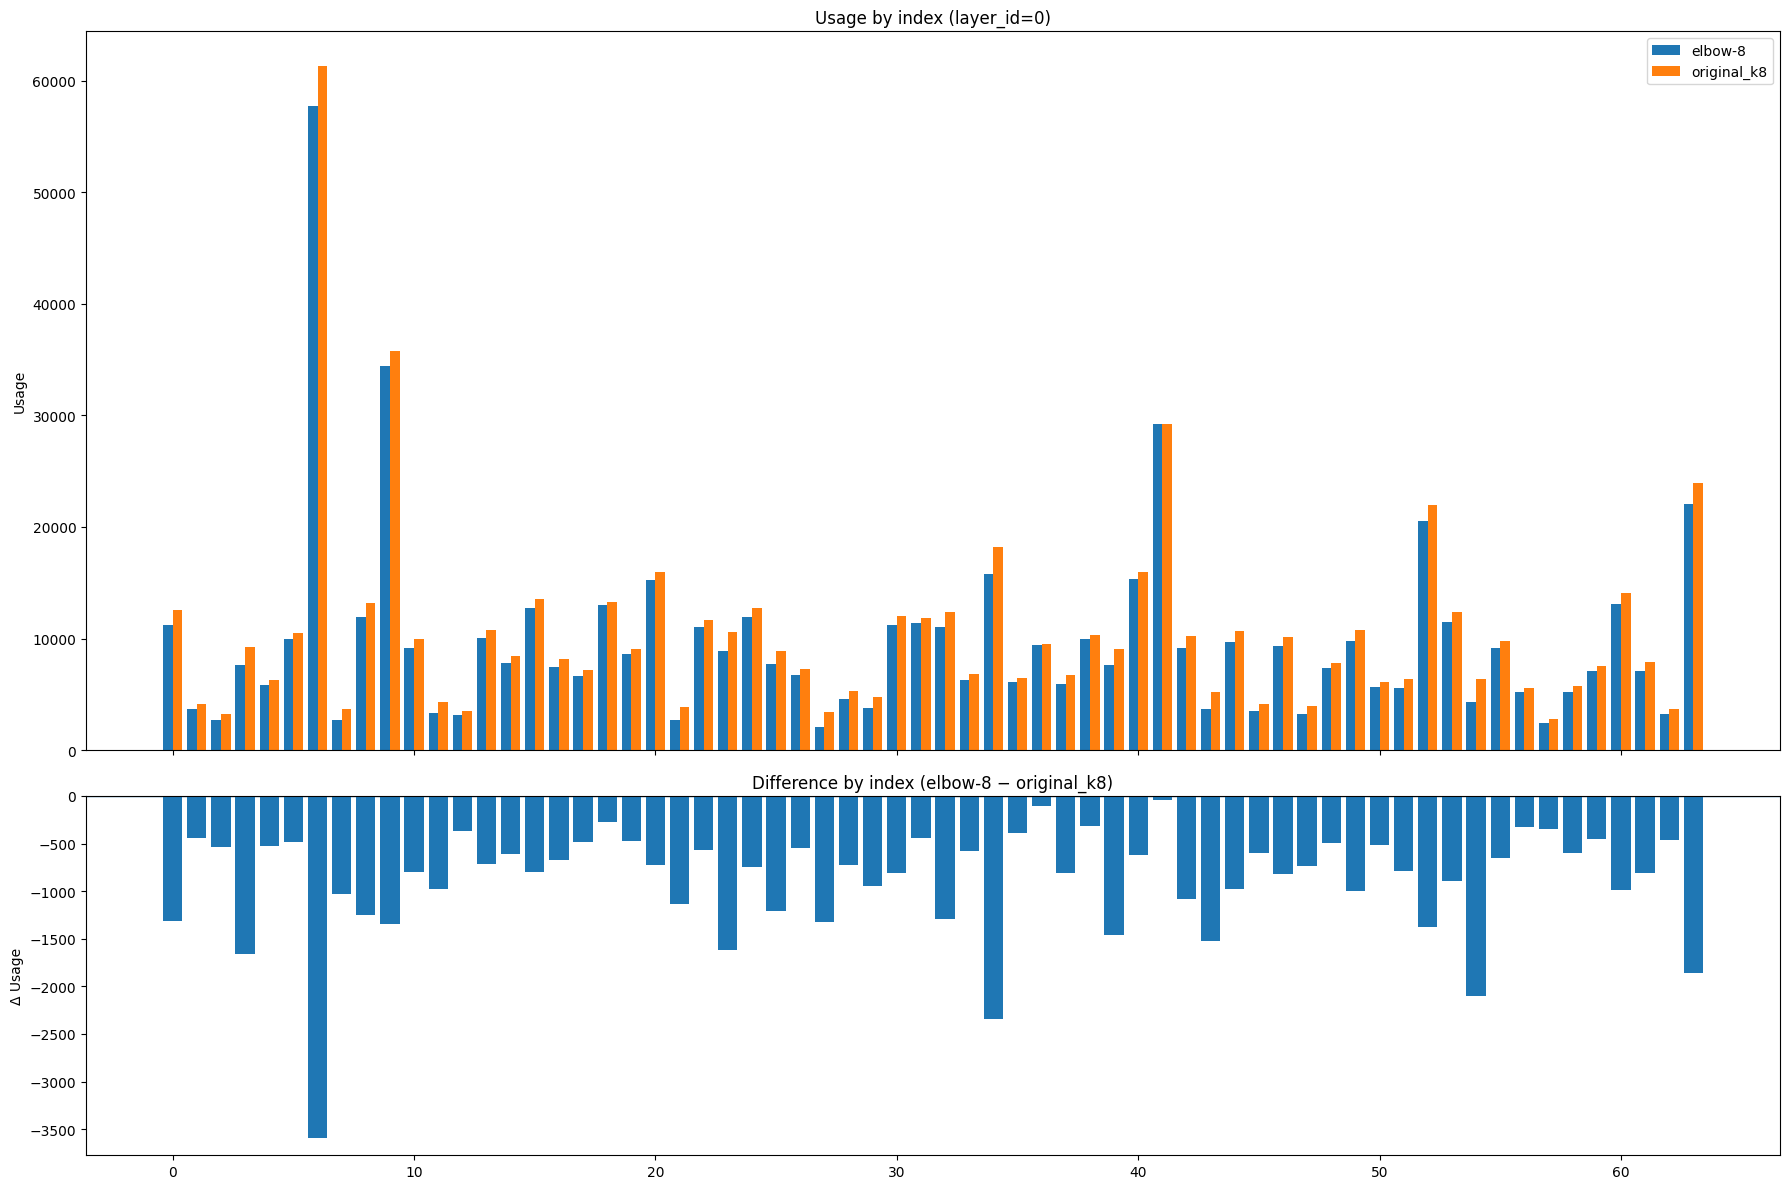

In [ ]:
# Bar plot of 64 usage values for layer_id=0, comparing two methods side-by-side per index
# + difference (elbow-8 - original_k8)
# + percent difference relative to original_k8: 100 * (elbow-8 - original_k8) / original_k8

import numpy as np
import matplotlib.pyplot as plt

# ---- config ----
layer = 0
methods = ["elbow-8", "original_k8"]

# ---- filter + validate ----
df0 = arcchallengelb[arcchallengelb["layer_id"].eq(layer) & arcchallengelb["method"].isin(methods)].copy()

if df0.empty:
    raise ValueError(f"No rows found for layer_id={layer} and methods={methods}.")

counts = df0["method"].value_counts()
missing = [m for m in methods if m not in counts.index]
if missing:
    raise ValueError(f"Missing method(s) for layer_id={layer}: {missing}")

# If duplicates exist, pick the first (adjust if you want different behavior)
df0 = df0.sort_values("method").drop_duplicates(subset=["method"], keep="first")

usage_map = {}
for m in methods:
    u = df0.loc[df0["method"].eq(m), "usage"].iloc[0]
    arr = np.asarray(u, dtype=float)
    if arr.shape != (64,):
        raise ValueError(f"Expected 'usage' length 64 for method='{m}', got shape {arr.shape}.")
    usage_map[m] = arr

elbow = usage_map["elbow-8"]
orig  = usage_map["original_k8"]
diff  = elbow - orig

# Percent difference relative to original; handle zeros safely
pct = np.full_like(diff, np.nan, dtype=float)
mask = orig != 0
pct[mask] = 100.0 * diff[mask] / orig[mask]

# ---- plot (three rows) ----
x = np.arange(64)
width = 0.4

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(18, 12),
    gridspec_kw={"height_ratios": [2, 1]},
    sharex=True
)

# Top: grouped bars
ax1.bar(x - width/2, elbow, width, label="elbow-8")
ax1.bar(x + width/2, orig,  width, label="original_k8")
ax1.set_title(f"Usage by index (layer_id={layer})")
ax1.set_ylabel("Usage")
ax1.legend()

# Middle: difference
ax2.bar(x, diff)
ax2.axhline(0, linewidth=1)
ax2.set_title("Difference by index (elbow-8 − original_k8)")
ax2.set_ylabel("Δ Usage")

plt.tight_layout()
plt.show()

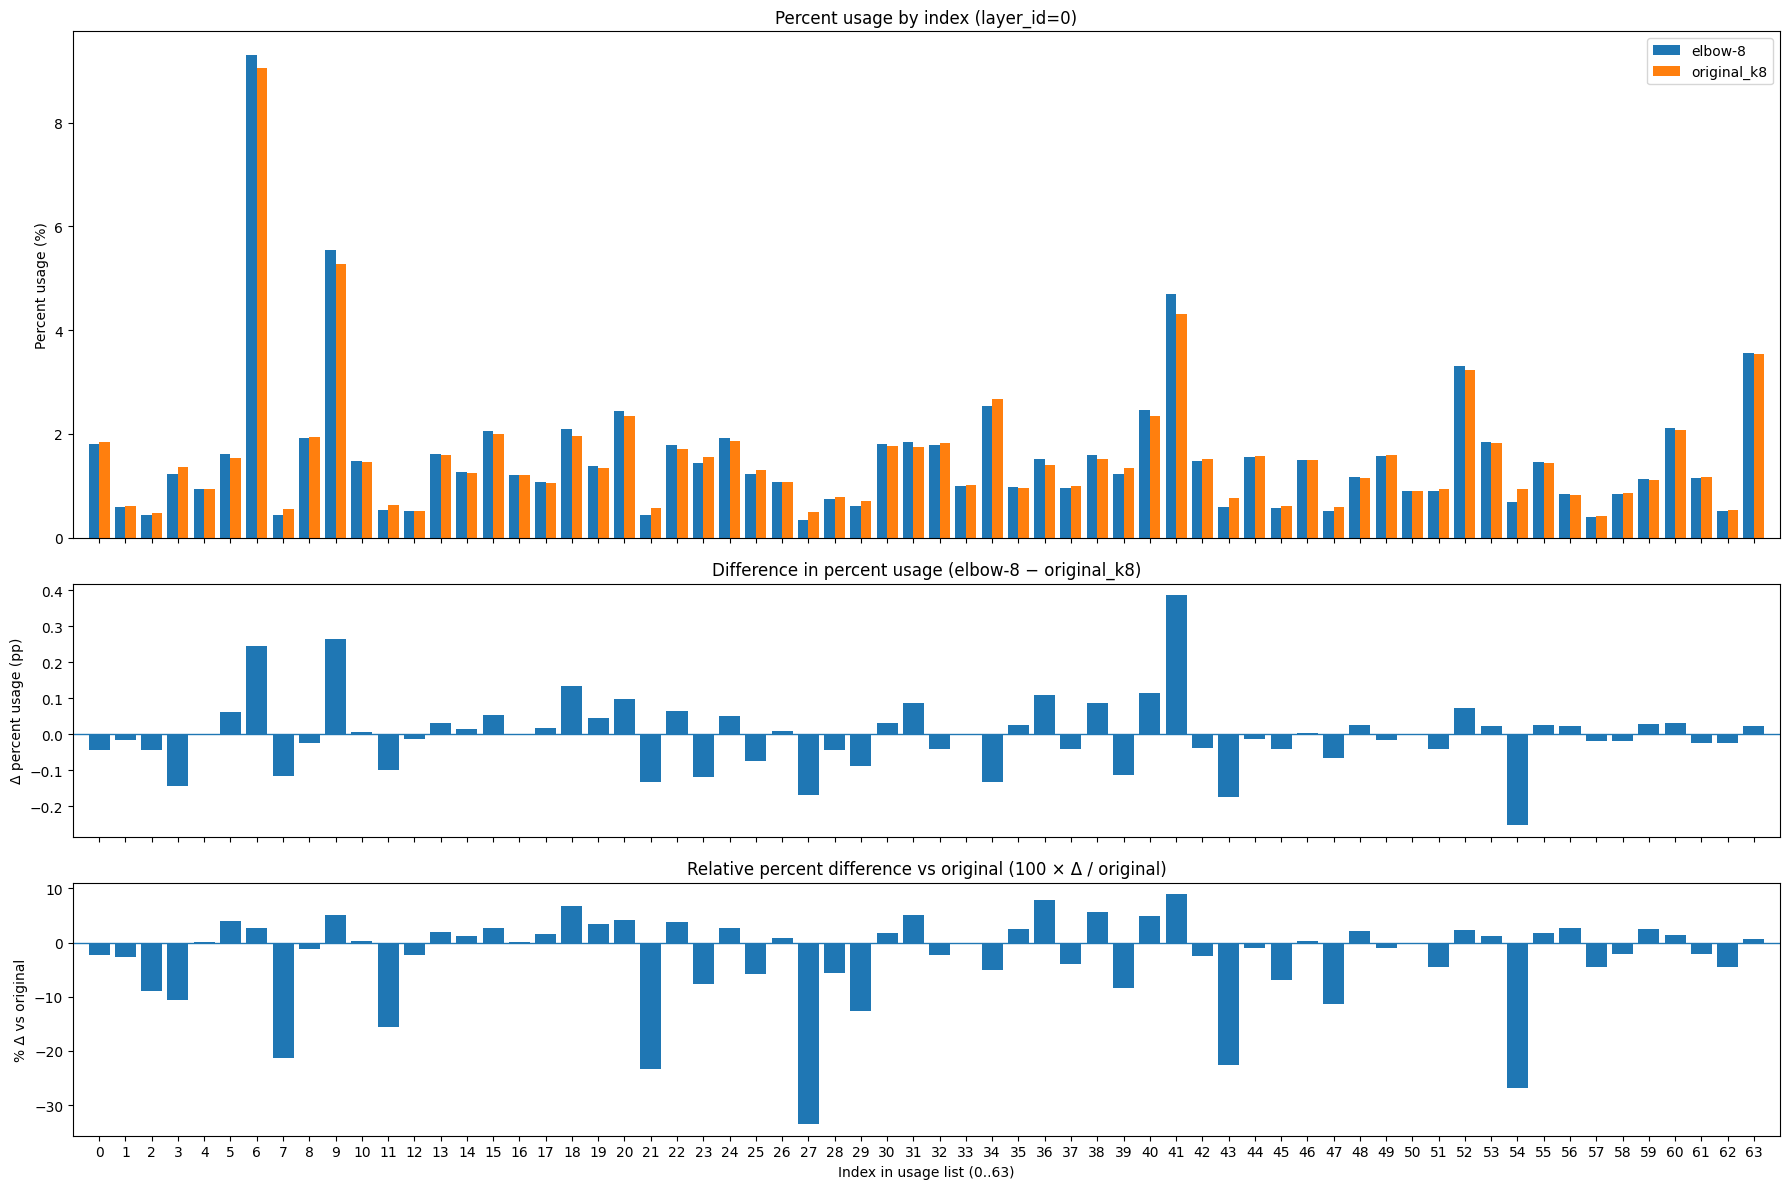

In [ ]:
# Plot percent usage (each value / sum(usage)) for layer_id=0, comparing methods
# + absolute difference in percent usage (percentage points)
# + relative percent difference vs original percent usage

import numpy as np
import matplotlib.pyplot as plt

layer = 0
methods = ["elbow-8", "original_k8"]

df0 = arcchallengelb[arcchallengelb["layer_id"].eq(layer) & arcchallengelb["method"].isin(methods)].copy()
if df0.empty:
    raise ValueError(f"No rows found for layer_id={layer} and methods={methods}.")

# If duplicates exist, keep the first per method (change if you want aggregation)
df0 = df0.sort_values("method").drop_duplicates(subset=["method"], keep="first")

def percent_usage(u, method_name: str) -> np.ndarray:
    arr = np.asarray(u, dtype=float)
    if arr.shape != (64,):
        raise ValueError(f"Expected 'usage' length 64 for method='{method_name}', got shape {arr.shape}.")
    s = arr.sum()
    if s == 0:
        raise ValueError(f"Sum of usage is 0 for method='{method_name}', cannot normalize.")
    return 100.0 * arr / s  # <-- percent usages

pu = {}
for m in methods:
    pu[m] = percent_usage(df0.loc[df0["method"].eq(m), "usage"].iloc[0], m)

elbow_pu = pu["elbow-8"]
orig_pu  = pu["original_k8"]

diff_pp = elbow_pu - orig_pu  # percentage points

rel_pct = np.full_like(diff_pp, np.nan, dtype=float)
mask = orig_pu != 0
rel_pct[mask] = 100.0 * diff_pp[mask] / orig_pu[mask]

x = np.arange(64)
width = 0.4

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(18, 12),
    gridspec_kw={"height_ratios": [2, 1, 1]},
    sharex=True
)

# 1) Percent usages (NOT raw)
ax1.bar(x - width/2, elbow_pu, width, label="elbow-8")
ax1.bar(x + width/2, orig_pu,  width, label="original_k8")
ax1.set_title(f"Percent usage by index (layer_id={layer})")
ax1.set_ylabel("Percent usage (%)")
ax1.legend()

# 2) Difference in percent usage (percentage points)
ax2.bar(x, diff_pp)
ax2.axhline(0, linewidth=1)
ax2.set_title("Difference in percent usage (elbow-8 − original_k8)")
ax2.set_ylabel("Δ percent usage (pp)")

# 3) Relative percent difference vs original percent usage
ax3.bar(x, rel_pct)
ax3.axhline(0, linewidth=1)
ax3.set_title("Relative percent difference vs original (100 × Δ / original)")
ax3.set_xlabel("Index in usage list (0..63)")
ax3.set_ylabel("% Δ vs original")

ax3.set_xticks(x)
ax3.set_xlim(-1, 64)

if np.any(~mask):
    zero_idxs = np.where(~mask)[0]
    ax3.text(
        0.01, 0.95,
        f"Note: original percent usage==0 at indices {zero_idxs.tolist()} → %Δ shown as NaN",
        transform=ax3.transAxes,
        va="top"
    )

plt.tight_layout()
plt.show()

